In [6]:
from main import *

In [ ]:
class SortLRL(nn.Module):
    def __init__(self, indim, latent, outdim):
        super().__init__()
        self.alpha = nn.Parameter(torch.randn(1, indim))
        self.lrl = nn.Sequential(
            nn.Linear(indim, latent),
            nn.ReLU(),
            nn.Linear(latent, outdim)
        )

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)
        # output: (batch_size, output_size)
        proj = (x @ self.alpha.T).squeeze(-1)
        proj = torch.sort(proj, dim=-1)
        return self.lrl(proj.values)

In [24]:
n, d, b = 113, 67, 256

torch.manual_seed(0)
alpha = nn.Parameter(torch.randn(1, d))
x = torch.randn(b, n, d)
proj = (x @ alpha.t()).squeeze(-1)
proj.sort(dim=-1).values

tensor([[-25.5718, -19.3112, -16.7619,  ...,  12.8538,  14.7268,  14.9576],
        [-21.2614, -17.1283, -15.4401,  ...,  17.2623,  18.1313,  22.5732],
        [-32.0957, -17.6581, -16.9428,  ...,  16.2247,  16.3664,  22.8824],
        ...,
        [-21.6984, -18.5206, -16.1354,  ...,  17.8503,  20.3774,  24.7162],
        [-23.4270, -17.4735, -16.8532,  ...,  18.0349,  19.3432,  20.2274],
        [-19.6067, -16.8753, -16.7871,  ...,  17.2244,  19.0643,  21.9052]],
       grad_fn=<SortBackward0>)

In [ ]:
import pickle
with open('models/F/args.pkl', 'rb') as f:
    args = pickle.load(f) 

In [53]:
overrides = OmegaConf.create({'num_q': 900})
argparse.Namespace(**OmegaConf.merge(OmegaConf.create(vars(args)), overrides))

Namespace(SNR=1, add_attention=False, b=1.0, b1=0.0, batch_size=400, cifar=False, dataset='longaudio2', debug=False, deepset=False, deepset_mode=2, delta=0.3, device=7, enforce_order=False, gapwt=0.0, human=False, internal_lamwt=1, lamwt=0.01, lfcc=False, lr=0.0005, lsun=False, n_sink_iter=20, neg_expl=400, nepochs=50, no_lammodel=False, no_lamrelu=False, no_tokenize=False, noise=0, num_q=900, preembed='tokenize', pretrain_budget=0.25, pretrain_embedding=False, pretrain_epochs=30, print_dataset=True, reproducible=1, seed=69, single_step_norm=-1, skip_embed=False, skip_type='lin', stagger=0, train_with_orig=False, use_linear_lammodel=False, use_sing_xfmer=False, video=False, wandb_log=False, xff=1024, xlr=5e-06, xnhead=4, xnumlayers=2, xoutdim=256, xwarmupepochs=20)

In [ ]:
argparse.Namespace

In [1]:
from main import *

In [2]:
import faiss

In [4]:
lsh = faiss.IndexLSH(20, 10)

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=10000, centers=10, n_features=2)

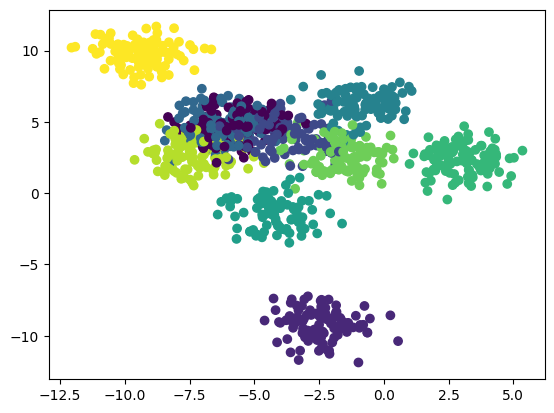

In [10]:
plt.scatter(X[::10, 0], X[::10, 1], c=y[::10])

In [30]:
X, y = make_blobs(n_samples=10000, centers=10, n_features=20)
lsh = faiss.IndexLSH(20, 10)
lsh.reset()
lsh.train(X[:5000])

In [34]:
lsh.add(X[501][None])

In [46]:
lsh.search(X[501][None], 4)

(array([[0.0000000e+00, 2.1474836e+09, 2.1474836e+09, 2.1474836e+09]],
       dtype=float32),
 array([[ 0, -1, -1, -1]]))

In [55]:
lsh.assign(X[5000][None], k=4)

array([[ 0, -1, -1, -1]])

In [8]:
d = {
    1: 2,
    0: 1,
    2: 3
}

In [ ]:
class SliceableDict(dict):
    def __getitem__(self, keys):
        if isinstance(keys, slice):
            return {k: self[k] for k in keys}
        return super().__getitem__(keys)

    def slice(self, *keys):
        return {k: self[k] for k in keys}
        # or one of the others from the first example

d = SliceableDict(d)
keys = 1, 0
d.slice(1, 0), d.slice(*keys)     # {1: 2, 5: 6}

({1: 2, 0: 1}, {1: 2, 0: 1})

In [ ]:
class CustomDict(dict):
    def __getattr__(self, name):
        return self[name]

# LSH

In [1]:
from train_prehash import *
import lshashpy3 as lshash

# expt_id = "S28021253"
expt_id = "A01091914"
root_dir = f"hashing/{expt_id}"

import pickle
with open(f"{root_dir}/args.pkl", 'rb') as f:
    args = pickle.load(f)

DEVICE = "cuda:1"

hasher = torch.load(f"{root_dir}/hasher_best.pt", map_location=DEVICE)
hasher = hasher.eval()

dataset = args.dataset
DATA_ROOT = f"final_data/{dataset}"
TRAIN_FILE = f"{DATA_ROOT}/dataset_train.hdf5"
VAL_FILE = f"{DATA_ROOT}/dataset_val.hdf5"
TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"

neg_expl = args.neg_expl
train_dataset = PairDatasetTest(TRAIN_FILE)
val_dataset = PairDatasetTest(VAL_FILE)
test_dataset = PairDatasetTest(TEST_FILE)

In [2]:
print(train_dataset.c.shape, val_dataset.c.shape, test_dataset.c.shape)
global_corpus = np.concatenate([train_dataset.c, val_dataset.c, test_dataset.c], axis=0)
print(global_corpus.shape)

(9600, 20, 4000) (5296, 20, 4000) (4864, 20, 4000)
(19760, 20, 4000)


In [ ]:
with torch.no_grad():
    self.q_emb = embed_full_corpus(DummyDataset(self.q), embed_model, preembed_model)
    self.c_emb = embed_full_corpus(DummyDataset(self.c), embed_model, preembed_model)
    self.qcscores = get_all_pair_scores(self.q_emb, self.c_emb, models=models, args=args)
    self.q = hasher[0](self.q_emb).cpu()
    self.c = hasher[1](self.c_emb).cpu()

(19760, 20, 4000)

In [3]:
model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_root=f"models/{expt_id}/", device=DEVICE, args=args)
model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
if aggregator is not None:
    aggregator.eval()

for m in [model, scoremodel, embed_model, preembed_model]:
    for param in m.parameters():
        param.requires_grad = False

image_embed_model = None
name_replace = lambda x: x.replace(".hdf5", "_orig.hdf5")
if "cifar" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
    image_embed_model = Autoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TRAIN_FILE = name_replace(TRAIN_FILE)
    VAL_FILE = name_replace(VAL_FILE)
    TEST_FILE = name_replace(TEST_FILE)

if "lsun" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
    image_embed_model = LSUNAutoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TRAIN_FILE = name_replace(TRAIN_FILE)
    VAL_FILE = name_replace(VAL_FILE)
    TEST_FILE = name_replace(TEST_FILE)

Loading `best` model


In [4]:
class DummyDataset:
    def __init__(self, arr):
        self.c = arr

with torch.no_grad():
    global_corpus_embedded = hasher[1](embed_full_corpus(DummyDataset(global_corpus), embed_model, preembed_model, image_embed_model, 800, aggregator)).cpu()
    test_queries_embedded = hasher[0](embed_full_corpus(DummyDataset(test_dataset.q), embed_model, preembed_model, image_embed_model, 800, aggregator)).cpu()

print(global_corpus_embedded.shape, test_queries_embedded.shape)

torch.Size([19760, 20]) torch.Size([3040, 20])


# custom lsh

In [ ]:
from multiprocessing import Pool

class LSH(object):
    def __init__(self, hash_size, input_dim, num_hashtables, hyperplanes_file, device='cpu'):
        self.m = hash_size
        self.L = num_hashtables
        self.d = input_dim

        self.device = device
        self.hyperplanes_file = hyperplanes_file

        self._init_tables()
        self._init_planes()

    def _init_planes(self):
        try:
            self.planes = torch.load(self.hyperplanes_file, map_location=self.device).detach()
            assert self.planes.shape == (self.L, self.m, self.d), f"Expected {(self.L, self.m, self.d)}, got {self.planes.shape}"
        except:
            print("Initializing random planes...")
            self.planes = torch.randn(self.L, self.m, self.d, device=self.device)

    def _init_tables(self):
        self.tables = [{} for _ in range(self.L)]

    @staticmethod
    def _cvt_index_to_hashstr(i):
        return "".join(map(str, map(int, i.cpu().numpy())))

    def index(self, corpus):
        # corpus: (n, d)
        st = perf_counter()
        self.corpus = corpus
        
        hashcodes = self.hashall(corpus)
        for t in range(self.L):
            unique_codes = torch.unique(hashcodes[t], dim=0)
            for code in unique_codes:
                key = self._cvt_index_to_hashstr(code)
                lsh.tables[t][key] = torch.where(torch.all(hashcodes[t] == code, dim=1))[0].cpu().long()
        print(f"Indexed {len(corpus)} items in {perf_counter() - st:.2f}s")

    def hashall(self, tensor):
        # tensor: (n, d)
        tensor = torch.atleast_2d(tensor)
        hashcodes = 0.5 * (torch.einsum("nmd,bd->nbm", self.planes, tensor.to(self.device)).sign() + 1)
        return hashcodes.squeeze()

    def _query_single(self, query):
        # query: (1, d) or (d)
        hashcodes = self.hashall(query)
        result_idxs = []
        for t, code in enumerate(hashcodes):
            key = self._cvt_index_to_hashstr(code)
            matches = self.tables[t].get(key, torch.tensor([]))
            if len(matches) > 0:
                result_idxs.append(matches)
        result_idxs = torch.cat(result_idxs).unique()
        return self.corpus[result_idxs], result_idxs

    def _query_single_loose(self, query, kbits):
        # returns all items where first k bits of hash match
        hashcodes = self.hashall(query)
        result_idxs = []
        for t, code in enumerate(hashcodes):
            key = self._cvt_index_to_hashstr(code)
            matching_keys = [k for k in self.tables[t].keys() if k[:kbits] == key[:kbits]]
            for mk in matching_keys:
                matches = self.tables[t].get(mk, torch.tensor([]))
                if len(matches) > 0:
                    result_idxs.append(matches)
        result_idxs = torch.cat(result_idxs).unique()
        return self.corpus[result_idxs], result_idxs

    def query(self, query, k, distance_func="cosine", kbits=None):
        # query: (1, d) or (d)
        if kbits is not None:
            matches, match_idxs = self._query_single_loose(query, kbits)
        else:
            matches, match_idxs = self._query_single(query)

        if distance_func == "cosine":
            f = LSH.CosineSimilarity
        elif distance_func == "euclidean" or distance_func == "mse":
            f = LSH.EuclideanDistance 

        distances = f(query[None].repeat_interleave(len(matches), dim=0), matches)
        topk = distances.topk(k=k if k else len(distances)).indices
        return matches[topk], match_idxs[topk], distances
    
    def query_batch(self, queries, k, distance_func="cosine", kbits=None):
        # TODO implement batch version
        # queries: (n, d)
        return [self.query(q, k, distance_func, kbits) for q in queries]
    
    @staticmethod
    def CosineSimilarity(x, y):
        return 0.5 * (F.cosine_similarity(x, y) + 1)

    @staticmethod
    def EuclideanDistance(x, y):
        return -(x - y).pow(2).sum(dim=-1).sqrt()

In [51]:
nbits = 10
L = 20
data_dim = global_corpus_embedded.shape[-1]

lsh = LSH(
    hash_size=nbits,
    input_dim=data_dim,
    num_hashtables=L,
    hyperplanes_file=f'{root_dir}/hyperplanes_10_1153.pkl',
    device=DEVICE
)
lsh.index(global_corpus_embedded)

Indexed 19760 items in 1.93s


In [52]:
test_labels_locs = test_dataset.l + len(train_dataset.c) + len(val_dataset.c)
test_labels = torch.zeros(len(test_dataset.q), len(global_corpus_embedded))

for i in range(len(test_dataset.q)):
    test_labels[i, test_labels_locs[i]] = 1

In [103]:
i = 0
query = test_queries_embedded[i]
retrieved, distances = lsh.query(query, k=None, distance_func="cosine", kbits=7)[1:]
ranked_output = test_labels[i][retrieved][None]
print(f"Retrieved {len(retrieved)} items, {ranked_output.sum().int()} relevant")

ap = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
ap /= (torch.arange(ranked_output.shape[1]) + 1)
ap /= torch.sum(ranked_output, dim=1, keepdim=True)
ap = ap.sum(dim=1).mean().item()
ap

Retrieved 4760 items, 5 relevant


0.0012400519335642457

In [85]:
dd = distances.topk(len(distances)).values.reshape(-1,1)
ddr = torch.cat((dd, ranked_output.T), dim=1)

import pandas as pd
pd.set_option("display.precision", 4)

pd.DataFrame(ddr, columns=["similarity", "label"]).to_csv("sim.csv")

In [70]:
dd[torch.where(ranked_output[0] == 1)[0]]

tensor([0.0561, 0.0522, 0.0510, 0.0490])

In [76]:
torch.where(dd == dd[torch.where(ranked_output[0] == 1)[0]][3])[0]

tensor([560])

# plots

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

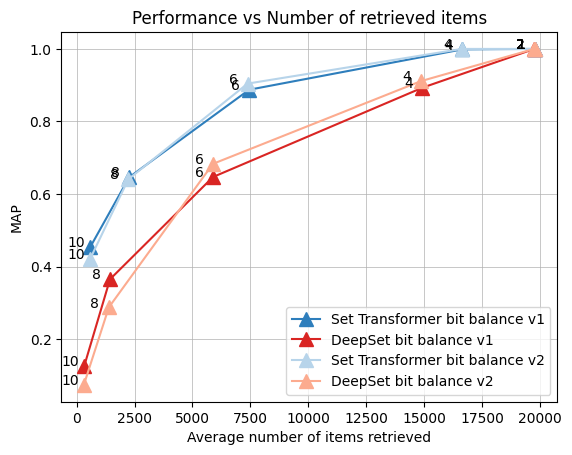

In [22]:
# ls = [0.031875, 530.38, 0.51, 0.193125, 2422.58, 3.09, 0.5575, 9136.06, 8.92, 0.99875, 19122.79, 15.98, 1.0, 19760.0, 16.0, 1.0, 19760.0, 16.0]
# ls = [0.031875, 530.38, 0.51, 0.193125, 2422.58, 3.09, 0.5575, 9136.06, 8.92, 0.99875, 19122.79, 15.98, 1.0, 19760.0, 16.0, 1.0, 19760.0, 16.0]
lss = [
    [0.454375, 596.39, 7.27, 0.64625, 2272.86, 10.34, 0.8875, 7444.67, 14.2, 0.99875, 16633.51, 15.98, 1.0, 19754.65, 16.0, 1.0, 19760.0, 16.0],
    [0.126875, 336.57, 2.03, 0.365, 1442.91, 5.84, 0.646875, 5883.8, 10.35, 0.893125, 14916.68, 14.29, 1.0, 19738.36, 16.0, 1.0, 19760.0, 16.0], # deepset
    [0.420625, 582.63, 6.73, 0.640625, 2232.34, 10.25, 0.904375, 7376.74, 14.47, 1.0, 16616.32, 16.0, 1.0, 19753.47, 16.0, 1.0, 19760.0, 16.0],   # set transformer bb v2
    [0.07375, 314.56, 1.18, 0.2875, 1392.4, 4.6, 0.683125, 5880.22, 10.93, 0.91125, 14853.98, 14.58, 1.0, 19737.13, 16.0, 1.0, 19760.0, 16.0], 
    # [0.124375, 291.49, 1.99, 0.288125, 1416.78, 4.61, 0.6375, 5640.71, 10.2, 0.94125, 14397.42, 15.06, 1.0, 19718.12, 16.0, 1.0, 19760.0, 16.0],    # deepset, using kron, val metric index
    # [0.255625, 569.84, 4.09, 0.57125, 2183.31, 9.14, 0.8275, 7363.86, 13.24, 0.981875, 16645.52, 15.71, 1.0, 19751.92, 16.0, 1.0, 19760.0, 16.0],   # set transformer, using kron, val metric index
    # [0.1425, 575.17, 2.28, 0.350625, 2135.31, 5.61, 0.653125, 7225.76, 10.45, 0.93125, 16572.57, 14.9, 1.0, 19753.52, 16.0, 1.0, 19760.0, 16.0],
    # [0.083125, 280.46, 1.33, 0.214375, 1325.74, 3.43, 0.600625, 5378.65, 9.61, 0.865, 14120.72, 13.84, 1.0, 19708.39, 16.0, 1.0, 19760.0, 16.0]
]
expt_label = ["Set Transformer bit balance v1", "DeepSet bit balance v1", "Set Transformer bit balance v2", "DeepSet bit balance v2"]
colors = {"st": list(plt.cm.Blues(np.linspace(0.3, 0.7, len(lss)//2))), "ds": list(plt.cm.Reds(np.linspace(0.3, 0.7, len(lss)//2)))}

for i, ls in enumerate(lss):
    typ = "st" if "Transformer" in expt_label[i] else "ds"
    MAP = ls[::3]
    avg_items = ls[1::3]
    avg_relevant = ls[2::3]
    kbits = [10, 8, 6, 4, 2, 1]

    plt.plot(avg_items, MAP, '^-', color=colors[typ].pop(), markersize=10, label=expt_label[i])
    plt.xlabel("Average number of items retrieved")
    plt.ylabel("MAP")
    for j, txt in enumerate(kbits):
        x, y = -1, 0 # list(map(int, list(bin(i)[2:].zfill(2))))
        plt.annotate(f"{int(txt)}", (avg_items[j], MAP[j]), textcoords="offset points", xytext=(x*10,y*10), ha='center', fontsize=10)
    plt.title("Performance vs Number of retrieved items")
    plt.grid(linewidth=0.5)
    # plt.semilogx()
plt.legend()
plt.show()

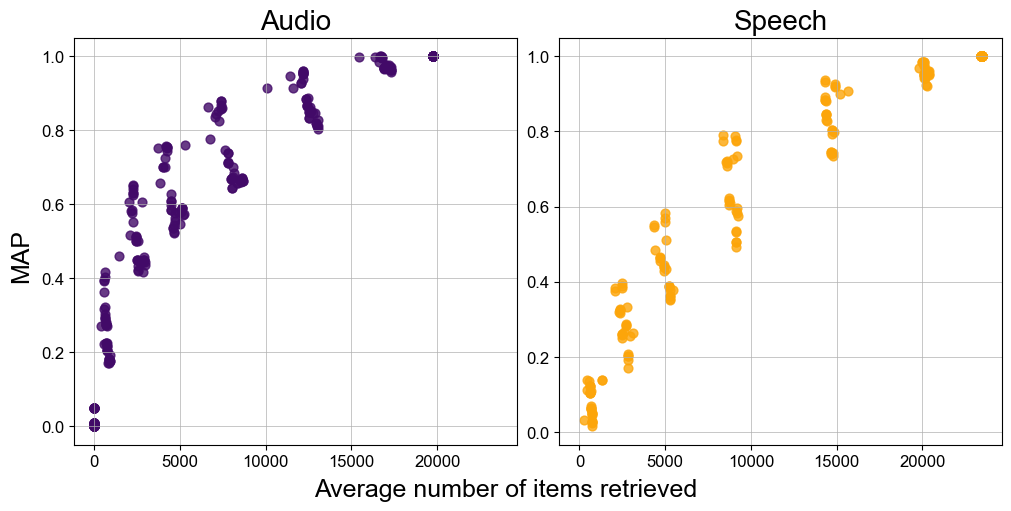

In [3]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

font = font_manager.FontEntry(fname="plots_and_figures/arial.ttf", name="Arial")
font_manager.fontManager.ttflist.append(font)

mpl.rcParams['font.family'] = "Arial"


plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 20
label_fontsize = 12

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, constrained_layout=True)
fig.supxlabel("Average number of items retrieved", fontsize=axis_fontsize)
fig.supylabel("MAP", fontsize=axis_fontsize)
colors = plt.cm.inferno(np.linspace(0.2, 0.8, 2))

for d, dataset in enumerate(["audio", "speech"]):
    with open(f"plots_and_figures/data/lsh_multi_final_{dataset}.pkl", "rb") as f:
        lss = pickle.load(f)

    for i, ls in enumerate(lss):
        info = ls[:3]
        ls = ls[3:]
        MAP = ls[::3]
        avg_items = ls[1::3]
        avg_relevant = ls[2::3]
        kbits = [10, 8, 7, 6, 5, 4, 2, 1]
        if i == 0:
            ax[d].scatter(avg_items, MAP, s=40, alpha=0.8, color=colors[d], label=f"{dataset.capitalize()}")
        else:
            ax[d].scatter(avg_items, MAP, s=40, alpha=0.8, color=colors[d])
        ax[d].tick_params(axis='both', which='major', labelsize=label_fontsize)
        ax[d].set_title(f"{dataset.capitalize()}", fontsize=title_fontsize)
        ax[d].grid(linewidth=0.5)

# legend = fig.legend(loc='upper center', ncol=2, fontsize=15)
# coords = legend.get_window_extent().get_points()[0]
# fig.legends = []
# scale = fig.get_window_extent().get_points()[1]
# fig.legend(bbox_to_anchor=(coords[0]/scale[0], coords[1]/scale[1]+0.2), loc=2, ncol=2, fontsize=15)
plt.show()

AttributeError: 'Legend' object has no attribute 'get_labels'

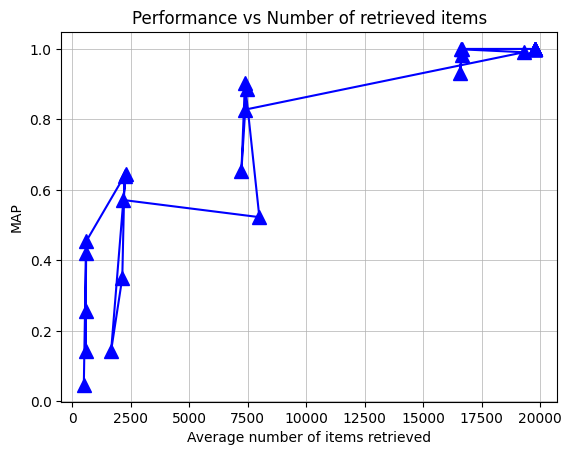

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

expt = "A01091914/24/"
file = f"hashing/{expt}/lsh_perf.csv"
df = pd.read_csv(file, header=None)

kbits, MAP, avg_items, avg_relevant = df.values.T
sort_idx = np.argsort(kbits)
kbits, MAP, avg_items, avg_relevant = kbits[sort_idx], MAP[sort_idx], avg_items[sort_idx], avg_relevant[sort_idx]

plt.plot(avg_items, MAP, '^-', markersize=10, color='blue')
plt.xlabel("Average number of items retrieved")
plt.ylabel("MAP")
for i, txt in enumerate(kbits):
    plt.annotate(f"{int(txt)}", (avg_items[i], MAP[i]), textcoords="offset points", xytext=(-10,0), ha='center')
plt.title("Performance vs Number of retrieved items")
plt.grid(linewidth=0.5)
# plt.semilogx()
plt.show()

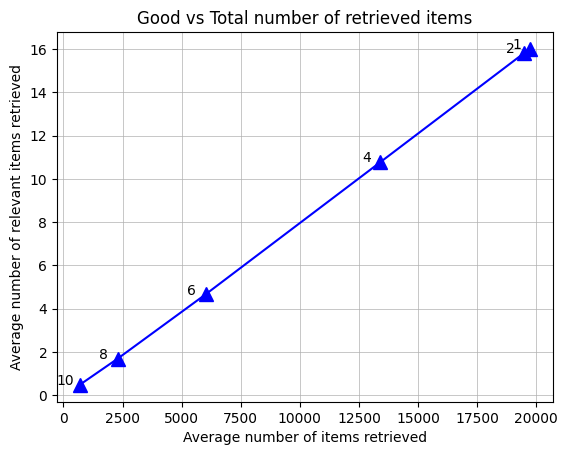

In [ ]:
plt.plot(avg_items, avg_relevant, '^-', markersize=10, color='blue')
plt.xlabel("Average number of items retrieved")
plt.ylabel("Average number of relevant items retrieved")
for i, txt in enumerate(kbits):
    plt.annotate(f"{int(txt)}", (avg_items[i], avg_relevant[i]), textcoords="offset points", xytext=(-10,0), ha='center')
plt.title("Good vs Total number of retrieved items")
plt.grid(linewidth=0.5)
# plt.semilogx()
plt.show()

# cifar

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

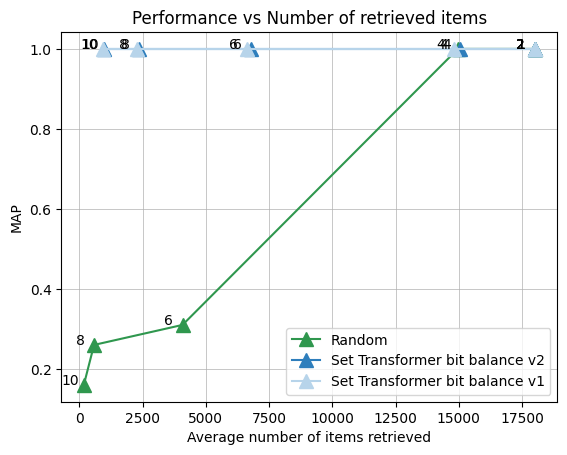

In [16]:
# for k in kbits: print(f"{MAP[k]}, {np.mean(num_matches[k])}, {np.mean(num_relevant[k])}")
# print([i for j in [(MAP[k], np.mean(num_matches[k]), np.mean(num_relevant[k])) for k in kbits] for i in j])

lss = [
    [0.16, 180.5, 1.6, 0.26, 583.97, 2.6, 0.30999999999999994, 4080.43, 3.1, 1.0, 14962.25, 10.0, 1.0, 18000.0, 10.0, 1.0, 18000.0, 10.0],
    # [0.19999999999999996, 1278.07, 2.0, 0.19999999999999996, 3288.36, 2.0, 0.96, 7966.63, 9.6, 1.0, 15403.39, 10.0, 1.0, 17988.18, 10.0, 1.0, 18000.0, 10.0],   # !!! RERUNNING !!! 
    [1.0, 977.34, 10.0, 1.0, 2356.74, 10.0, 1.0, 6803.22, 10.0, 1.0, 15050.48, 10.0, 1.0, 17996.05, 10.0, 1.0, 18000.0, 10.0],
    [1.0, 947.11, 10.0, 1.0, 2297.26, 10.0, 1.0, 6637.9, 10.0, 1.0, 14822.15, 10.0, 1.0, 17995.44, 10.0, 1.0, 18000.0, 10.0]
]
expt_label = ["Random", "Set Transformer bit balance v2", "Set Transformer bit balance v1"]
colors = {"st": list(plt.cm.Blues(np.linspace(0.3, 0.7, int(np.ceil(len(lss)/2))))), "ds": list(plt.cm.Reds(np.linspace(0.3, 0.7, int(np.ceil(len(lss)/2))))), "rng": list(plt.cm.Greens(np.linspace(0.3, 0.7, int(np.ceil(len(lss)/2)))))}

for i, ls in enumerate(lss):
    typ = "st" if "Transformer" in expt_label[i] else "ds"
    typ = "rng" if "Random" in expt_label[i] else typ
    MAP = ls[::3]
    avg_items = ls[1::3]
    avg_relevant = ls[2::3]
    kbits = [10, 8, 6, 4, 2, 1]

    plt.plot(avg_items, MAP, '^-', color=colors[typ].pop(), markersize=10, label=expt_label[i])
    plt.xlabel("Average number of items retrieved")
    plt.ylabel("MAP")
    for j, txt in enumerate(kbits):
        x, y = -1, 0 # list(map(int, list(bin(i)[2:].zfill(2))))
        plt.annotate(f"{int(txt)}", (avg_items[j], MAP[j]), textcoords="offset points", xytext=(x*10,y*10), ha='center', fontsize=10)
    plt.title("Performance vs Number of retrieved items")
    plt.grid(linewidth=0.5)
    # plt.semilogx()
plt.legend()
plt.show()

In [4]:
import torch
from tqdm import tqdm

W, B, d = 13, 68, 128
a = torch.randn(W, B, d)

assert torch.vmap(torch.vmap(torch.kron))(a, a).shape == (W, B, d*d)
aa = torch.vmap(torch.kron)(a, a)

In [5]:
bbkron = torch.vmap(torch.vmap(torch.kron))
aa = bbkron(a, a)                             # (nplanes, batch_size, nbits**2)
aa.shape

torch.Size([13, 68, 16384])

In [6]:
torch.vmap(torch.vmap(torch.kron))(a, a).shape 

torch.Size([13, 68, 16384])

In [9]:
for w in range(W):
    for b in range(B):
        assert torch.allclose(aa[w][b], torch.kron(a[w][b], a[w][b]), atol=1e-5)
        # for i in range(d):
        #     for j in range(d):
        #         assert aa[w][b][i*d + j] == a[w][b][i] * a[w][b][j]

# lib lsh

In [ ]:
import lshashpy3 as lshash
from sklearn.datasets import make_blobs

nbits = 10
L = 20
q = test_queries_embedded.numpy()
C = global_corpus_embedded.numpy()
# C, y = make_blobs(n_samples=20000, centers=10, n_features=20)
data_dim = C.shape[1]

lsh = lshash.LSHash(
    hash_size=nbits,
    input_dim=data_dim,
    num_hashtables=L,    
    storage_config={ 'dict': None },
    matrices_filename=f'{root_dir}/weights.npz',
    hashtable_filename=f'{root_dir}/hash.npz',
    overwrite=False
)

for i, x in enumerate(C):
    lsh.index(x, extra_data=str(i))

In [ ]:
def query(lsh, point, k=5, distance_func="cosine"):
    query_result = lsh.query(point, num_results=k, distance_func=distance_func)
    for res in query_result:
        print(res[0], res[1])

5

In [ ]:
lsh._hash(lsh.uniform_planes[0], q[0])

'1100110011'

In [ ]:
len(lsh.hash_tables[0].get_list(lsh._hash(lsh.uniform_planes[0], q[0])))

13

In [ ]:
res = lsh.query(q, num_results=10, distance_func="cosine")
[len(r) for r in res]

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [ ]:
plane = np.random.randn(nbits, data_dim)

index = 0.5 * (np.sign(C @ plane.T) + 1)
np.unique(index, axis=0).shape

keys = ["".join(map(str, map(int, i))) for i in index]
np.unique(keys).shape

(8,)

[]